# 01. Integral norms: estimators and convergence

**Project:** Principled loss functions for continuous-time learning
**Purpose:** establish the baseline loss against which path-wise losses will be compared, and determine its accuracy.

---

## 0. Notes.

For $f:[0,T]\to\mathbb{R}^d$,

$$\|f\|_{L^p} \;=\; \Big(\int_0^T |f(t)|^p\,\mathrm{d}t\Big)^{1/p},$$

and the loss is $\|\,\hat f - f\,\|_{L^p}$ for a prediction $\hat f$.

We hold samples $(t_i, f(t_i))_{i=0}^{n}$, not $f$. The computed object is therefore a quadrature rule

$$\|f\|_{L^p}^p \;\approx\; \sum_{i=0}^{n} w_i \,|f(t_i)|^p ,$$

and the open question is the choice of $w_i$.

Pointwise MSE is the case $w_i = 1/n$, correct only on a uniform grid. On an irregular grid the correct weights are $w_i \approx \Delta t_i$; the two disagree, MSE over-weighting densely sampled regions. §4 measures the disagreement, §7 identifies it with a known estimator problem.

The ML literature on irregularly sampled data (Che et al., 2018; Rubanova et al., 2019; Shukla & Marlin, 2021; Kidger et al., 2020) modifies the model to ingest irregular observations while leaving the objective as pointwise MSE. An objective that re-weights the time axis by observation density is not corrected by architecture. §7.5.

### Purpose within project

The six-week aim is to investigate path-wise losses for path-to-path learning, i.e. what it means for two rough paths to be "close". This notebook establishes a baseline for comparison.

| Section | Purpose |
|---|---|
| §§1 to 3 | **Certification.** Bound the quadrature error, so no later difference between losses is attributable to numerical error. |
| §4 | **Empirical foundation.** Demonstrate and explain the MSE/$L^2$ divergence. If this fails, the premise fails. |
| §5 | **Hyperparameter.** Fix $p=2$ as the default. |
| §§6 to 6.1 | **Next steps.** Measure path roughness, which sets the number of signature levels required in weeks 3 to 5: $\lfloor p\rfloor$ for finite $p$-variation. |
| §7 | **Positioning.** Separate standard practice from open questions. |

Weeks 2 to 4 inherit the estimator built here.

> **Parallel with sFML.** There, a uniform average over a non-uniformly visited *state* space; here, a uniform average over a non-uniformly sampled *time* axis.

## 1. Quadrature rules

### 1.1 The problem

Given samples $(t_i, f(t_i))_{i=0}^{n}$ on $[0,T]$, we want

$$I(g) \;=\; \int_0^T g(t)\,\mathrm{d}t, \qquad g = |f|^p \ \text{ or } \ |r|^p, \quad r = \hat f - f .$$

We hold values only at the $t_i$, so any estimator is a weighted sum

$$Q_w(g) \;=\; \sum_{i=0}^{n} w_i\, g(t_i).$$

The $t_i$ are given, not chosen. The only thing to decide is $w$.

Nothing is assumed about $f$ beyond having sampled it. The question is then: **which weights are defensible knowing that little?**

### 1.2 A rule should get simple functions right

The weakest useful demand: if a rule cannot integrate a function as simple as a constant or a straight line, it is wrong in a case where nothing has gone wrong with the data. Testing the two rules on $\int_0^1 g$ with 120 points:

| grid | rule | $g=1$ | $g=t$ | $g=t^2$ |
|---|---|---|---|---|
| uniform | trapezoid | $0$ | $0$ | $1.2\times10^{-5}$ |
| uniform | uniform $w_i = 1/n$ | $10^{-16}$ | $10^{-17}$ | $1.4\times10^{-3}$ |
| clustered, $t=u^{0.35}$ | trapezoid | $0$ | $0$ | $1.2\times10^{-3}$ |
| clustered, $t=u^{0.35}$ | uniform $w_i = 1/n$ | $10^{-16}$ | $\mathbf{0.24}$ | $0.25$ |

Both rules integrate constants exactly. Only trapezoid integrates straight lines exactly, and it does so **on any grid**. Uniform weights get lines right only when the sample times happen to be symmetric about the midpoint, which is why the defect is invisible on a uniform grid and 48% of the true value on a clustered one.

That single row is the argument for trapezoid. Reproduced in `test_trapezoid_is_exact_on_constants_and_lines_for_any_grid` and its counterpart.

### 1.3 What the weights mean

$$w_i \;=\; \tfrac12(\Delta t_{i-1} + \Delta t_i)$$

is the length of the stretch of time for which $t_i$ is the nearest observation. Each sample speaks for the interval around it, and no more. Uniform weights give every sample an equal say regardless of how much time it represents, which is why they over-count crowded regions.

Two immediate consequences, neither requiring an assumption about $f$:

- $\sum_i w_i = \sum_i \Delta t_i = T$, by telescoping. The intervals tile $[0,T]$ exactly once.
- Trapezoid replaces $g$ by its chord on each interval, so the error is whatever $g$ does by bending away from that chord. When $g$ has a bounded second derivative,

$$\big|I(g) - Q_w(g)\big| \;\le\; \tfrac{T}{12}\,h_{\max}^2\,\|g''\|_\infty ,$$

with $h_{\max}$ the largest gap. Accuracy is limited by curvature and by the widest gap, not by the number of samples as such. When $g$ has no such bound, §3 measures what happens instead.

### 1.4 Why not something higher-order

**Simpson** fits a parabola to three consecutive points, but its weights $\tfrac{h}{3}(1,4,2,\dots,4,1)$ are derived with the middle node at the midpoint. On unequal spacing the coefficients change for every triple, so the standard formula is a different rule, not an inaccurate one.

**Gauss-Legendre** attains exactness to degree $2n-1$ with $n$ nodes, but only by placing them at the roots of $P_n$. It requires choosing where to sample.

| rule | exact up to degree | needs |
|---|---|---|
| left Riemann | 0 | nothing |
| **trapezoid** | **1** | **nothing** |
| Simpson | 3 | uniform spacing, odd $n$ |
| Gauss-Legendre | $2n-1$ | control of the node positions |

With the nodes given, trapezoid is the most accurate rule available. Simpson and Gauss-Legendre appear later only as high-accuracy reference values on grids we do control. Error terms as in Davis & Rabinowitz (1984).

### 1.5 The same weights arrive from three other directions

Corroboration rather than argument, but the agreement is worth recording.

**Signal processing.** Non-uniform FFT and MRI reconstruction estimate an inverse Fourier integral from off-lattice samples. Equal weighting over-counts the densely sampled centre and blurs the image; the correction is inverse local sample density, called **density compensation factors**.

**Survey sampling.** Weighting an observation by the inverse of its inclusion probability gives the Horvitz-Thompson estimator (1952), unbiased under any sampling design. If the times are drawn from a density $\rho$, the expected spacing of order statistics is $\mathbb{E}[t_{(i+1)} - t_{(i)}] \approx 1/(n\rho(t_{(i)}))$, so $\Delta t_i$ *is* an inverse-probability weight with $\rho$ estimated from the gaps. No knowledge of $\rho$ is needed. §4 and §7.2 develop this.

**Bayesian quadrature.** Put a prior on $f$, condition on the observed values, and take the weights minimising the posterior variance of $\int f$. Under a Brownian motion prior, which encodes continuity and nothing further, the posterior mean is the piecewise linear interpolant and its integral is exactly the trapezoidal rule (Diaconis, 1988). Assuming differentiability instead returns splines. So trapezoid is the optimal rule under the weakest assumption one can make about $f$, which is the position we are in.

### 1.6 The caution: bias against variance

Unequal weights are not free. Normalise $\tilde w_i = w_i / \sum_j w_j$; for observations with independent noise of variance $\sigma^2$,

$$\operatorname{Var}\Big(\sum_i \tilde w_i Y_i\Big) \;=\; \sigma^2 \sum_i \tilde w_i^{\,2},
\qquad \sum_i \tilde w_i^{\,2} \;\ge\; \frac1n \ \text{(Cauchy-Schwarz)},$$

with equality iff all weights are equal.

> Equal weights minimise variance. Trapezoid weights minimise bias. Nothing does both.

The Kish effective sample size $n_{\mathrm{eff}} = 1/\sum_i \tilde w_i^{\,2}$ measures the cost, on the §4 grids with $n=120$:

| grid | $n_{\mathrm{eff}}$ | variance inflation | $w_{\max}/w_{\min}$ |
|---|---|---|---|
| uniform | 119.5 | $1.00\times$ | 2.0 |
| clustered, $t = u^{0.35}$ | 30.7 | $3.91\times$ | 81.1 |

Zhang & Wang (2016) show the preferable choice reverses with sampling density. Godambe (1955) proved that no best linear unbiased estimator exists even under simple random sampling, so the absence of an unconditional recommendation is a theorem rather than a gap. §4 exhibits a regime in which the bias dominates; it does not establish a universal rule.

Observation noise also biases the raw estimator upward. With $Y_j = f(t_j) + \varepsilon_j$ and $p=2$,

$$\mathbb{E}\big[Q_w(Y^2)\big] \;=\; \sum_j w_j\big(f(t_j)^2 + \sigma^2\big) \;=\; \int_0^T f^2 \;+\; \sigma^2 T + O(h^2),$$

using $\sum_j w_j = T$. The bias $\sigma^2 T$ does not depend on $w$, so it is common to MSE and to the weighted norm, cancelling in §4 while contaminating absolute values. Removing it requires smoothing before integrating, as in the penalised basis expansion of Ramsay & Silverman (2005, ch. 3 to 5), which we do not implement.

### 1.7 Decisions

1. **Verify the weights against closed forms** (§2). §4 rests on them.
2. **Do not test convergence on a periodic integrand alone** (§2). Euler-Maclaurin makes that case degenerate.
3. **Do not claim noise robustness.** That requires smoothing before integrating. We integrate raw samples, and therefore earn the irregular-sampling claim only.
4. **Report variance alongside bias.** Quote $n_{\mathrm{eff}}$ with every loss value.

$p$-variation differs: there the computation itself is open. §6.1.

### 1.8 Implementation notes

Both tested in `tests/test_norms.py`.

1. **Overflow at large $p$.** Factor out $M=\max_t|f(t)|$: $\|f\|_p = M\big(\int (|f|/M)^p\big)^{1/p}$.
2. **$|\cdot|$ for $d>1$.** Channels collapsed with the Euclidean norm before integration, giving $\big(\int \|f(t)\|_2^p\,\mathrm{d}t\big)^{1/p}$. Not the $\ell^p$ combination of per-channel norms; standard for $L^p([0,T];\mathbb{R}^d)$ and rotation-invariant in channel space.

In [1]:
%matplotlib inline
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from pathloss.norms import (
    quadrature_weights, integral_norm, integral_distance,
    pointwise_mse, p_variation_dyadic,
)
from pathloss.paths import (
    smooth_test_path, ornstein_uhlenbeck, brownian_motion,
    subsample_irregular,
)

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (10, 3.6), "figure.dpi": 110})
print("numpy", np.__version__)

numpy 2.2.6


## 2. Verification against an analytic value

A rule is trustworthy only if it reproduces a known value, for every $p$ rather than $p=2$ alone.

Take $f(t) = \sin(2\pi k t)$ on $[0,1]$, $k \in \mathbb{N}$. With $u = 2\pi k t$,

$$\int_0^1 |\sin(2\pi kt)|^p\,\mathrm{d}t
\;=\; \frac{1}{2\pi k}\int_0^{2\pi k}|\sin u|^p\,\mathrm{d}u
\;=\; \frac{2k}{2\pi k}\int_0^{\pi}\sin^p u\,\mathrm{d}u
\;=\; \frac1\pi\int_0^\pi \sin^p u\,\mathrm{d}u,$$

since $|\sin|$ has period $\pi$ and $[0,2\pi k]$ contains $2k$ copies. The remaining integral is a Beta function, giving

$$\|f\|_{L^p}^p \;=\; \frac1\pi B\!\left(\tfrac{p+1}{2}, \tfrac12\right).$$

At $p=2$, $B(3/2,1/2) = \pi/2$, so $\|f\|_{L^2} = 1/\sqrt2 \approx 0.7071068$.

In [2]:
from scipy.special import beta as beta_fn

def analytic_sin_norm(p):
    # ||sin(2 pi k t)||_{L^p([0,1])} for integer k
    return (beta_fn((p + 1) / 2, 0.5) / np.pi) ** (1 / p)

t, x = smooth_test_path(n=2049, T=1.0, freq=3.0)

rows = []
for p in [1, 2, 3, 4, 8]:
    exact = analytic_sin_norm(p)
    est   = integral_norm(t, x, p=p, rule="trapezoid")
    rows.append((p, exact, est, abs(est - exact)))

print(f"{'p':>3} {'exact':>12} {'trapezoid':>12} {'abs err':>11}")
for p, e, a, err in rows:
    print(f"{p:>3} {e:>12.8f} {a:>12.8f} {err:>11.2e}")

  p        exact    trapezoid     abs err
  1   0.63661977   0.63661927    4.99e-07
  2   0.70710678   0.70710678    1.11e-16
  3   0.75150110   0.75150110    2.77e-13
  4   0.78254229   0.78254229    0.00e+00
  8   0.85036869   0.85036869    0.00e+00


### Convergence rates

**Prediction.** For $g \in C^2$ the trapezoid error is $O(h^2)$, left-Riemann $O(h)$. On a log-log plot against $n = 1/h$, slopes $-2$ and $-1$.

**Degeneracy.** Euler-Maclaurin expresses the trapezoid error as

$$\int_a^b g \;=\; h\Big[\tfrac12 g_0 + g_1 + \cdots + \tfrac12 g_n\Big] \;-\; \sum_{k\ge1}\frac{B_{2k}}{(2k)!}\,h^{2k}\Big[g^{(2k-1)}(b) - g^{(2k-1)}(a)\Big] \;+\;\cdots$$

Every term is a difference of odd derivatives at the endpoints. For smooth periodic $g$ these vanish, the series is zero, and convergence is spectral. The rectangle rule coincides with trapezoid up to one endpoint and inherits this.

$\sin^2(2\pi k t)$ on $[0,1]$ is such a case (Trefethen & Weideman, 2014). We therefore test both a periodic integrand and $f(t)=e^{t}$, for which $\|f\|_{L^2}^2 = (e^2-1)/2$.

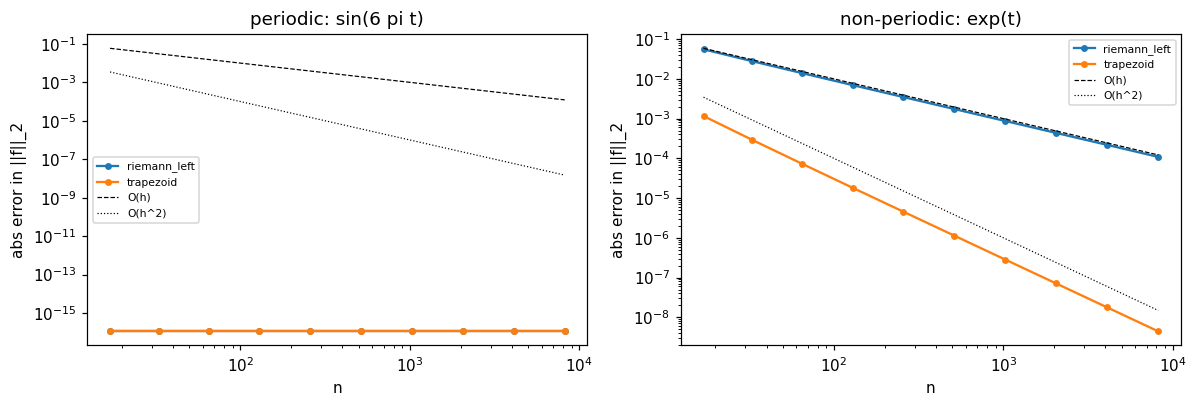

periodic      riemann slope    nan | trapezoid slope    nan
non-periodic  riemann slope  -1.01 | trapezoid slope  -2.01

(nan = error already at machine precision at every n; see note below)


In [3]:
def conv_study(f, exact, ns, rules=("riemann_left", "trapezoid"), p=2):
    out = {r: [] for r in rules}
    for n in ns:
        tt = np.linspace(0.0, 1.0, n)
        xx = f(tt)[:, None]
        for r in rules:
            out[r].append(abs(integral_norm(tt, xx, p=p, rule=r) - exact))
    return out

ns = np.array([2**k + 1 for k in range(4, 14)])

# (a) periodic integrand
exact_a = analytic_sin_norm(2)
conv_a = conv_study(lambda tt: np.sin(2 * np.pi * 3 * tt), exact_a, ns)

# (b) non-periodic integrand: ||e^t||_{L2}^2 = (e^2 - 1)/2
exact_b = np.sqrt((np.exp(2) - 1) / 2)
conv_b = conv_study(np.exp, exact_b, ns)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, conv, title in [(axes[0], conv_a, "periodic: sin(6 pi t)"),
                        (axes[1], conv_b, "non-periodic: exp(t)")]:
    for r, e in conv.items():
        e = np.maximum(np.array(e), 1e-17)
        ax.loglog(ns, e, "o-", ms=3.5, label=r)
    ax.loglog(ns, 1.0 / ns, "k--", lw=0.8, label="O(h)")
    ax.loglog(ns, 1.0 / ns**2.0, "k:", lw=0.8, label="O(h^2)")
    ax.set_xlabel("n"); ax.set_ylabel("abs error in ||f||_2"); ax.set_title(title)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

def slope(ns, errs):
    # fitted log-log slope, ignoring points already at machine precision
    e = np.array([float(v) for v in errs]); m = e > 1e-14
    if m.sum() < 3:
        return np.nan   # rule converged too fast to fit a rate
    return np.polyfit(np.log(ns[m]), np.log(e[m]), 1)[0]

print("periodic      riemann slope %6.2f | trapezoid slope %6.2f"
      % (slope(ns, conv_a['riemann_left']), slope(ns, conv_a['trapezoid'])))
print("non-periodic  riemann slope %6.2f | trapezoid slope %6.2f"
      % (slope(ns, conv_b['riemann_left']), slope(ns, conv_b['trapezoid'])))
print("\n(nan = error already at machine precision at every n; see note below)")

The non-periodic column gives the rates: $-1.01$ for Riemann, $-2.01$ for trapezoid. The periodic column reports `nan` because both rules reach machine precision at the coarsest grid tested, as Euler-Maclaurin predicts. A convergence test on a periodic integrand is therefore uninformative about the order of the rule.

On smooth synthetic data with $n\gtrsim 500$ the quadrature error is $O(10^{-6})$ or smaller and is not a confounder for §4.

## 3. Rough paths: degradation of the rate

The above assumes a smooth integrand. The project's data is SDE trajectories.

**Prediction.** Brownian paths are $\alpha$-Hölder for $\alpha < 1/2$ and nowhere differentiable, so Euler-Maclaurin does not apply and a deterministic bound gives only $O(h^{\alpha}) \to O(n^{-1/2})$.

That bound is pessimistic: the per-interval errors are mean-zero and cancel. On one interval,

$$\int_{t_i}^{t_{i+1}} W_s\,\mathrm{d}s \;-\; \tfrac{h}{2}\big(W_{t_i} + W_{t_{i+1}}\big)$$

is a Brownian bridge integral with mean zero and variance $\Theta(h^3)$. Summing $n$ independent terms,

$$\operatorname{Var}(\text{total error}) \;\approx\; n\cdot\Theta(h^3) \;=\; \Theta(h^2)
\qquad\Longrightarrow\qquad \text{error} \;=\; \Theta(n^{-1}).$$

Expect a slope near $-1$: better than $-1/2$ through cancellation, worse than $-2$ for want of a second derivative.

Below, $\|W\|_{L^2}$ on progressively coarser subsamples of one fixed fine path, the finest grid serving as reference.

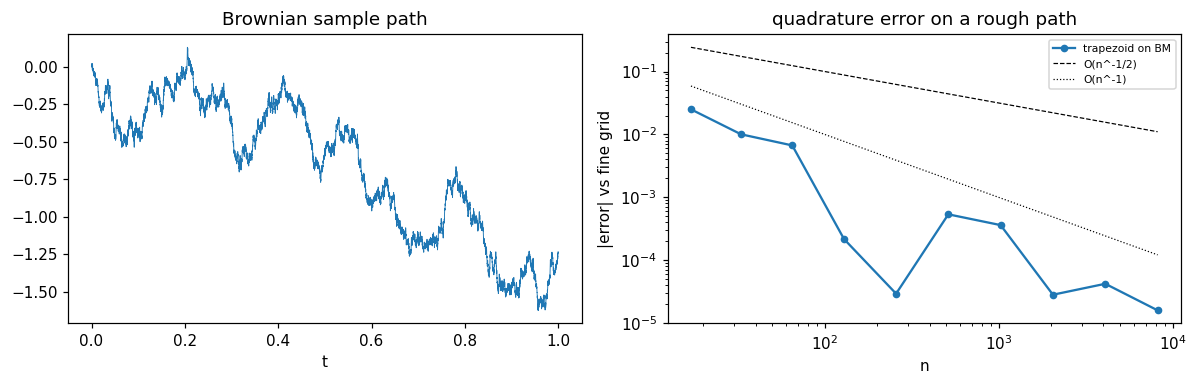

fitted slope on BM: -1.12


In [4]:
t_fine, W = brownian_motion(n=2**14 + 1, T=1.0, d=1, rng=1)
ref = integral_norm(t_fine, W, p=2)

levels, errs = [], []
for k in range(4, 14):
    step = 2 ** (14 - k)
    tt, xx = t_fine[::step], W[::step]
    levels.append(tt.size)
    errs.append(abs(integral_norm(tt, xx, p=2) - ref))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(t_fine, W[:, 0], lw=0.6)
axes[0].set_title("Brownian sample path"); axes[0].set_xlabel("t")
axes[1].loglog(levels, errs, "o-", ms=4, label="trapezoid on BM")
axes[1].loglog(levels, np.array(levels, float) ** -0.5, "k--", lw=0.8, label="O(n^-1/2)")
axes[1].loglog(levels, np.array(levels, float) ** -1.0, "k:", lw=0.8, label="O(n^-1)")
axes[1].set_xlabel("n"); axes[1].set_ylabel("|error| vs fine grid"); axes[1].legend(fontsize=7)
axes[1].set_title("quadrature error on a rough path")
plt.tight_layout(); plt.show()

print("fitted slope on BM: %.2f" % np.polyfit(np.log(levels), np.log(errs), 1)[0])

## 4. MSE against the integral norm under irregular sampling

Fix $f$ and $\hat f$ on a fine grid, write $r = \hat f - f$, and score the same pair on two observation grids with equal numbers of points.

### Limits of the two quantities

Both are weighted sums of $r(t_i)^2$:

$$\underbrace{\mathrm{MSE} = \frac1n\sum_{i=1}^n r(t_i)^2}_{w_i \,=\, 1/n},
\qquad
\underbrace{\frac1T\|r\|_{L^2}^2 \approx \frac1T\sum_i w_i\,r(t_i)^2}_{w_i \,\approx\, \Delta t_i}.$$

For sample times drawn with density $\rho$ on $[0,T]$, $\int_0^T \rho = 1$, the law of large numbers gives

$$\mathrm{MSE} \;\longrightarrow\; \int_0^T r^2\,\rho ,
\qquad
\frac1T\|r\|_{L^2}^2 \;\longrightarrow\; \frac1T\int_0^T r^2 .$$

These agree iff $\rho \equiv 1/T$.

> MSE integrates the squared residual against the **sampling density**; the integral norm integrates it against **Lebesgue measure**.

### The grid used below

For $t_i = u_i^{\alpha}$, $u_i$ uniform, $\alpha = 0.35$: inverting gives $u = t^{1/\alpha}$, hence

$$\rho(t) = \frac{\mathrm{d}u}{\mathrm{d}t} = \frac1\alpha t^{\frac1\alpha - 1} = 2.857\,t^{1.857},$$

increasing, so sparse early and dense late. With $r(t) = 0.4t$ both limits are closed-form:

$$\sqrt{\int_0^1 r^2\rho} = 0.4\sqrt{\frac{1/\alpha}{1/\alpha+2}} = 0.30679,
\qquad
\sqrt{\int_0^1 r^2} = \frac{0.4}{\sqrt3} = 0.23094.$$

### Two failure modes

The underlying functions do not change between grids, so any valid measure returns the same value on both. Two mechanisms violate this:

| failure mode | cause | corrected by quadrature weights? |
|---|---|---|
| **weighting** | equal weight per sample over-counts dense regions | **yes**, the role of $\Delta t_i$ |
| **resolution** | the grid does not sample where the residual lives | **no**, the information is absent |

Hence two runs: **(a)** a ramp residual both grids resolve, isolating the weighting effect and testing the prediction above; **(b)** a narrow spike the clustered grid misses, bounding what reweighting can achieve.

In [5]:
T = 1.0
t_fine = np.linspace(0, T, 2**13 + 1)
base = np.sin(2 * np.pi * 2 * t_fine)

# --- residual (a): smooth ramp, resolved by BOTH grids -----------------------
# r(t) = 0.4 t. Non-uniform in time (grows), but nowhere near band-limited by
# the sampling, so any sensible quadrature sees all of it.
g_true = base
g_pred = base + 0.4 * t_fine

# --- residual (b): narrow spike at t = 0.125, MISSED by the clustered grid ---
centre, width, amp = 0.125, 0.075, 0.8
bump = amp * np.exp(-0.5 * ((t_fine - centre) / (width / 2.5)) ** 2)
f_true = base
f_pred = base + bump

n_keep = 120
t_uniform = np.linspace(0, T, n_keep)
t_clustered = T * np.linspace(0, 1, n_keep) ** 0.35     # sparse early

def evaluate(tt, a_fine, b_fine):
    """Score a pair of fine-grid functions as observed on grid `tt`."""
    i = np.searchsorted(t_fine, tt).clip(0, t_fine.size - 1)
    a, b = a_fine[i][:, None], b_fine[i][:, None]
    return (float(integral_distance(tt, a, b, p=2, normalise=True)),
            float(np.sqrt(pointwise_mse(a, b))))

for label, (a_f, b_f) in [("(a) smooth ramp", (g_true, g_pred)),
                          ("(b) narrow spike", (f_true, f_pred))]:
    ref = float(integral_distance(t_fine, a_f[:, None], b_f[:, None], p=2, normalise=True))
    L2_u, MSE_u = evaluate(t_uniform, a_f, b_f)
    L2_c, MSE_c = evaluate(t_clustered, a_f, b_f)
    print(f"{label}   reference (fine grid) = {ref:.5f}")
    print(f"{'  grid':>12} {'L2 (quad)':>12} {'sqrt(MSE)':>12} {'L2 err':>9} {'MSE err':>9}")
    for name, L2, MSE in [("uniform", L2_u, MSE_u), ("clustered", L2_c, MSE_c)]:
        print(f"{name:>12} {L2:>12.5f} {MSE:>12.5f} "
              f"{abs(L2-ref)/ref:>8.1%} {abs(MSE-ref)/ref:>8.1%}")
    print()

(a) smooth ramp   reference (fine grid) = 0.23094
        grid    L2 (quad)    sqrt(MSE)    L2 err   MSE err
     uniform      0.23097      0.23145     0.0%     0.2%
   clustered      0.23136      0.30661     0.2%    32.8%

(b) narrow spike   reference (fine grid) = 0.18448
        grid    L2 (quad)    sqrt(MSE)    L2 err   MSE err
     uniform      0.18447      0.18370     0.0%     0.4%
   clustered      0.03106      0.00820    83.2%    95.6%



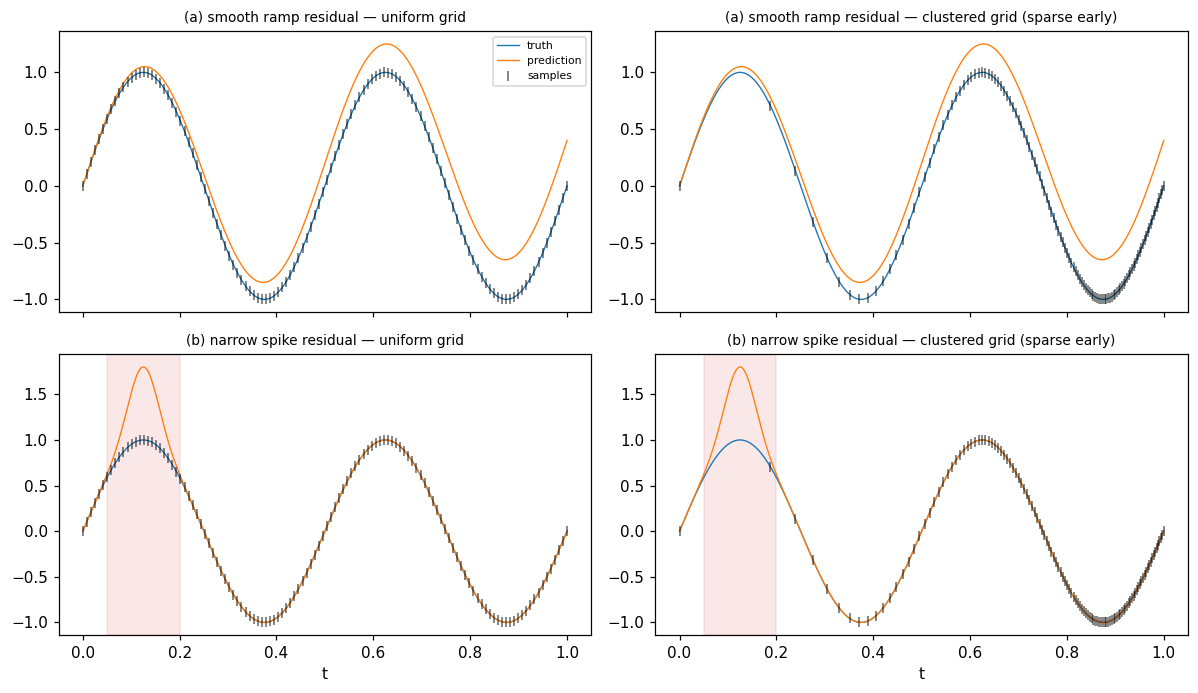

clustered grid has 3 of 120 points in [0, 0.25] (uniform has 30)


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), sharex=True)
for row, (a_f, b_f, tag, shade) in enumerate([
        (g_true, g_pred, "(a) smooth ramp residual", None),
        (f_true, f_pred, "(b) narrow spike residual", (centre - width, centre + width))]):
    for col, (tt, gname) in enumerate([(t_uniform, "uniform grid"),
                                       (t_clustered, "clustered grid (sparse early)")]):
        ax = axes[row, col]
        ax.plot(t_fine, a_f, lw=0.9, label="truth")
        ax.plot(t_fine, b_f, lw=0.9, label="prediction")
        i = np.searchsorted(t_fine, tt).clip(0, t_fine.size - 1)
        ax.plot(tt, a_f[i], "k|", ms=7, alpha=0.6, label="samples")
        if shade is not None:
            ax.axvspan(*shade, color="tab:red", alpha=0.10)
        ax.set_title(f"{tag} — {gname}", fontsize=9)
        if row == 1:
            ax.set_xlabel("t")
        if row == 0 and col == 0:
            ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

n_early = int((t_clustered < 0.25).sum())
print(f"clustered grid has {n_early} of {n_keep} points in [0, 0.25] "
      f"(uniform has {int((t_uniform < 0.25).sum())})")

**Row (a), weighting in isolation.** Both grids resolve a linear ramp, so only sample placement differs. The weighted $L^2$ distance returns the fine-grid value on both; MSE inflates by roughly a third on the clustered grid, the late-time samples being over-represented where the residual is largest.

The measured values match the predictions: $0.30679$ against $0.30661$ for MSE, $0.23094$ against $0.23094$ for $L^2$, to four significant figures. The compared quantities are $\int r^2\rho$ and $\int r^2$, as derived.

**Row (b), the limit of reweighting.** The clustered grid places 3 of 120 points in $[0, 0.25]$; the spike sits at $t = 0.125$. Both measures fail, $L^2$ included. Quadrature weights correct the averaging of observations, not their absence.

The defensible claim is therefore narrower than "MSE is wrong":

> Pointwise MSE and the $L^2$ integral norm diverge precisely when the residual and the sampling are both non-uniform in time. Quadrature weighting removes the divergence over the region the grid resolves.

Both conditions hold for irregular observation with time-localised model error, the generic case in clinical measurement, sensor networks and astronomy. By row (b), the robustness experiments in weeks 3 to 4 must report sampling density alongside every loss value.

### Identification with a known estimator

Writing $w_i \propto \Delta t_i \approx 1/(n\rho(t_i))$, the weighted distance is the **Horvitz-Thompson estimator** (1952) of $\int r^2$, unbiased under any inclusion probabilities. MSE is the unweighted estimator of the same integral, biased when they are unequal. The correction is standard rather than ad hoc.

The identification also accounts for row (b). IPW trades bias for variance, the variance diverging as inclusion probabilities approach zero. In row (b) the interval containing the spike is represented by three points over a quarter of the domain. The two failure modes are the two documented halves of IPW behaviour.

> **Parallel with sFML.** Row (b) has the structure of the noise-floor finding: a quantity differing between two models is invisible to the objective because the data does not separate them, not because the objective is poorly designed.

## 5. Sensitivity to $p$

**The ordering is forced.** On a probability space, and $[0,1]$ with Lebesgue measure is one, Lyapunov's inequality gives $\|r\|_{L^p} \le \|r\|_{L^q}$ for $p \le q$, with

$$\lim_{p\to\infty}\|r\|_{L^p} = \|r\|_{L^\infty} = \sup_t |r(t)| .$$

Larger $p$ concentrates the loss on the worst-behaved part of the path. The $T^{1/p}$ normalisation in `integral_distance` is required for comparability across $p$; without it the monotonicity is an artefact of the horizon.

Below, the localised-spike pair at several $p$. The value at $p=\infty$ should equal the spike amplitude.

p =    1 : 0.06016
p =    2 : 0.18448
p =    3 : 0.28117
p =    4 : 0.35228
p =    6 : 0.44766
p =    8 : 0.50836
p =  inf : 0.80000


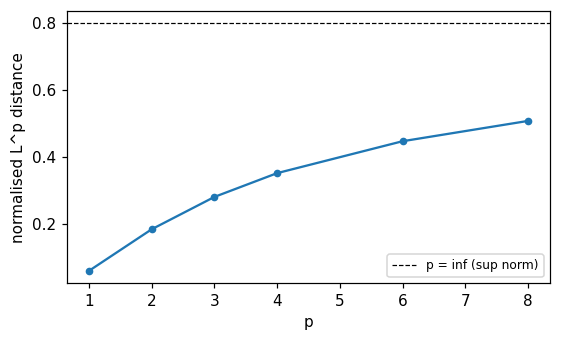

In [7]:
ps = [1, 2, 3, 4, 6, 8, np.inf]
vals = [integral_distance(t_fine, f_true[:, None], f_pred[:, None], p=p, normalise=True)
        for p in ps]
for p, v in zip(ps, vals):
    print(f"p = {str(p):>4} : {float(v):.5f}")

finite = [p for p in ps if np.isfinite(p)]
plt.figure(figsize=(5.2, 3.2))
plt.plot(finite, [float(v) for p, v in zip(ps, vals) if np.isfinite(p)], "o-", ms=4)
plt.axhline(float(vals[-1]), ls="--", c="k", lw=0.8, label="p = inf (sup norm)")
plt.xlabel("p"); plt.ylabel("normalised L^p distance"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

The normalised distance increases monotonically towards the sup norm, a localised spike being what large $p$ weights most heavily. $p=2$ is adopted: it is the value comparable to MSE, and the only $p$ for which $L^p$ is a Hilbert space, required once inner-product structure enters. $p=\infty$ is retained as a diagnostic.

## 6. $p$-variation

$\|f\|_{L^p}$ measures size; the $p$-variation

$$V_p(f) = \Big(\sup_{\mathcal{P}} \sum_i |f(t_{i+1}) - f(t_i)|^p\Big)^{1/p},
\qquad \mathcal{P}: 0 = t_0 < \cdots < t_m = T,$$

measures roughness. Four properties:

- **$V_p$ is non-increasing in $p$**, since increments of a fine partition are small and higher powers shrink them faster than the extra terms compensate. Note the opposite monotonicity to $\|f\|_{L^p}$.
- **$p=1$ is total variation.** $V_1 < \infty$ iff Riemann-Stieltjes integration against $f$ is defined, equivalently iff bounded-variation signatures exist.
- **Brownian motion has $V_p < \infty$ a.s. exactly for $p > 2$.** Hence $p=2$ is critical, and rough path theory requires level $\lfloor p\rfloor = 2$, one iterated integral beyond the path.
- **The supremum is over all partitions**, a combinatorial optimisation rather than a sum. Restricting to nested dyadic partitions gives a cheap lower bound; §6.1 quantifies the cost.

Unlike the $L^p$ case, computing $V_p$ is an open algorithmic question: Butkus & Norvaiša (2018) with the R package `pvar`, and Daoudi & Junca (2024).

Expected behaviour: as $p$ crosses the critical exponent, the dyadic estimate should change from diverging under refinement to stabilising.

    p           BM       smooth
  1.0      71.2622       8.0000
  1.5       4.0086       4.0000
  2.0       1.4447       2.8284
  2.5       1.4447       2.2974
  3.0       1.4447       2.0000


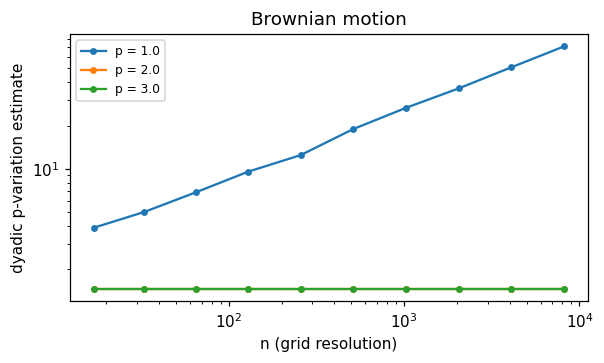

In [8]:
t_bm, Wp = brownian_motion(n=2**13 + 1, T=1.0, d=1, rng=7)
t_sm, Xs = smooth_test_path(n=2**13 + 1, freq=2.0)

print(f"{'p':>5} {'BM':>12} {'smooth':>12}")
for p in [1.0, 1.5, 2.0, 2.5, 3.0]:
    print(f"{p:>5} {p_variation_dyadic(Wp, p):>12.4f} {p_variation_dyadic(Xs, p):>12.4f}")

# refinement behaviour: does the estimate stabilise?
plt.figure(figsize=(5.6, 3.4))
for p in [1.0, 2.0, 3.0]:
    est = [p_variation_dyadic(Wp[::2**(13-k)], p) for k in range(4, 14)]
    plt.loglog([2**k + 1 for k in range(4, 14)], est, "o-", ms=3.5, label=f"p = {p}")
plt.xlabel("n (grid resolution)"); plt.ylabel("dyadic p-variation estimate")
plt.title("Brownian motion"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

$V_1$ grows without bound under refinement, Brownian paths not being of bounded variation; $V_3$ flattens; $p=2$ sits at the boundary, where the quadratic variation converges to $T$ in probability while the true 2-variation is a.s. infinite. That the dyadic estimate at $p=2$ appears convergent is a limitation of the estimator: **restricting to dyadic partitions gives a lower bound that can be badly non-tight at the critical exponent.** §6.1 quantifies this.

### 6.1 Cost of the dyadic restriction

`p_variation_dyadic` maximises over nested dyadic partitions at cost $O(n\log n)$, giving a weaker lower bound than the supremum. `p_variation_exact` optimises over all subsequences of the observed grid by dynamic programming: with $D[j]$ the largest sum ending at index $j$,

$$D[0] = 0, \qquad D[j] = \max_{i<j}\Big(D[i] + |x_j - x_i|^p\Big), \qquad V_p = D[n-1]^{1/p},$$

in $O(n^2)$ time and $O(n)$ memory. Still a lower bound on the continuous-time $V_p$, the path between samples being unobserved, but exact on the available grid.

**Why a search is required.** For $p>1$, merging increments $a, b$ of the same sign gives $|a+b|^p > |a|^p + |b|^p$, so coarsening can increase the sum and the optimal partition is not the finest. At $p=1$ equality holds, the finest partition is optimal, and $V_1$ is a cumulative sum, linear in $n$.

This is Ferrucci, Perrée & Lyons (2026, Remark 2.2): for $p=1$ an optimal split is a cumulative-sum problem and hence linear, whereas *"for the $p$-variation control with $p>1$ the analogous problem is computationally harder, since even computing the ordinary $p$-variation requires an optimisation over partitions."*

In [9]:
from pathloss.norms import p_variation_exact
import time

_, Wq = brownian_motion(n=2**9 + 1, T=1.0, d=1, rng=3)

print(f"{'p':>5} {'dyadic':>10} {'exact (DP)':>12} {'ratio':>8} {'t_dyad':>9} {'t_exact':>9}")
for p in [1.0, 1.5, 2.0, 2.5, 3.0]:
    t0 = time.perf_counter(); vd = p_variation_dyadic(Wq, p); t1 = time.perf_counter()
    ve = p_variation_exact(Wq, p); t2 = time.perf_counter()
    print(f"{p:>5} {vd:>10.4f} {ve:>12.4f} {ve/vd:>8.2f} "
          f"{t1-t0:>9.4f} {t2-t1:>9.4f}")

    p     dyadic   exact (DP)    ratio    t_dyad   t_exact
  1.0    17.8206      17.8206     1.00    0.0002    0.0043
  1.5     2.5383       3.6522     1.44    0.0001    0.0052
  2.0     1.4032       2.0784     1.48    0.0001    0.0040
  2.5     1.4032       1.8339     1.31    0.0002    0.0058
  3.0     1.4032       1.8037     1.29    0.0002    0.0052


## 7. Position in the literature

Five strands, separating standard practice from open questions.

### 7.1 Numerical integration on non-uniform grids

§§1 to 3 are textbook: error terms and rules in Davis & Rabinowitz (1984), the periodicity degeneracy in Trefethen & Weideman (2014). The weights appear across applied fields as **density compensation factors**, most visibly in non-uniform FFT and MRI reconstruction.

No novelty is claimed in §§1 to 3. Their function is to certify that the numerics are not a confounder for §4.

### 7.2 Survey sampling

The weighted estimator is Horvitz & Thompson (1952), and its bias/variance behaviour under near-zero inclusion probabilities accounts for row (b). Three consequences:

- The correction is principled rather than heuristic, and defensible by citation.
- The failure modes are already mapped, so misbehaviour can be predicted rather than discovered.
- The variance-reduction literature (stabilised, trimmed, self-normalised weights) applies if extreme grids destabilise training.

### 7.3 Functional data analysis

Ramsay & Silverman (2005) and Ferraty & Vieu (2006) give the basis-expansion and semi-metric machinery; Wang, Chiou & Müller (2016) review.

**Zhang & Wang (2016)** show the efficiency of equal weight per observation versus equal weight per subject reverses with sampling density: per subject for dense designs, per observation for sparse. The accurate statement of §4 is therefore:

> The preferable weighting is a bias/variance tradeoff depending on the sampling regime. Quadrature weights remove a bias and can add variance. §4 exhibits a regime in which the bias dominates.

Weaker than "MSE is the wrong loss", more defensible, and citable. It also fixes what must be measured in weeks 3 to 4: variance across resamplings, not bias alone.

### 7.4 Non-pointwise losses for time series

An active literature addresses losses beyond pointwise error, on a different axis from ours:

| | corrects | mechanism |
|---|---|---|
| soft-DTW (Cuturi & Blondel, 2017) | misalignment in time | differentiable relaxation of DTW alignment |
| DILATE (Le Guen & Thome, 2019) | shape and timing jointly | soft-DTW with a temporal distortion index |
| patch-wise structural loss (Kudrat et al., 2025) | local structure lost by MSE | patch statistics rather than points |
| **quadrature weighting (this notebook)** | the measure integrated against | $w_i \approx \Delta t_i$ |

DTW assumes reliable samples and wrong correspondence; we assume correct correspondence and wrong weighting. The axes are orthogonal and compose. Signature-based losses address both: reparametrisation invariance for alignment, the integral formulation for measure.

### 7.5 Irregular sampling in machine learning

GRU-D (Che et al., 2018), Latent ODEs (Rubanova et al., 2019), mTAN (Shukla & Marlin, 2021), Neural CDEs (Kidger et al., 2020), surveyed by Shukla & Marlin (2021).

All of it modifies the model, through decay mechanisms, continuous-time dynamics, attention over time or interpolated control paths, and leaves the objective as pointwise MSE or cross-entropy. How the architecture ingests irregular samples has been addressed; what measure the loss should integrate against has not.

By §4 the gap is not cosmetic: a model well designed for irregular sampling can still be trained against an objective that re-weights the time axis by observation density.

### 7.6 $p$-variation

Computing $V_p$ remains open: Butkus & Norvaiša (2018) and Daoudi & Junca (2024). The $O(n^2)$ dynamic program here is correct but naive.

### Summary

| section | status |
|---|---|
| §§1 to 3, quadrature | textbook; certification, not contribution |
| §4, weighting | rediscovery of Horvitz-Thompson; novelty in the application to path-to-path losses |
| §5, choice of $p$ | standard $L^p$ theory |
| §§6 to 6.1, $p$-variation | correct but naive; better algorithms exist |

No new mathematics. The unoccupied intersection is **continuous-time models trained on irregularly sampled data with a loss accounting for the sampling measure**, and §4 is evidence that it is non-empty.

At $p=1$ the two estimators agree, as derived. For $p>1$ the dyadic estimate understates the grid supremum by up to roughly 50%.

The dyadic value is identical at $p = 2, 2.5, 3$: the maximising dyadic partition has collapsed to $[0,T]$, returning $|W_T - W_0|$ for every $p$.

**Rule adopted.** Quote $p$-variation from the exact dynamic program for $n \lesssim 4000$; treat the dyadic value as a screening statistic. A claim that a path has finite $p$-variation for $p > p_0$ based on the dyadic estimate reports a lower bound as a measurement.

---

## Next steps

1. Port `integral_distance` to a differentiable torch loss in `src/pathloss/losses.py`, weights precomputed per batch, tested against the NumPy version.
2. Add the signature-kernel MMD using `sigkernel` and repeat §4 for it. Reparametrisation invariance predicts greater stability than the integral norm under changes of grid: a falsifiable prediction and a week 3 deliverable.
3. Repeat §4 with missingness in place of irregular sampling.
4. **Replace §4's two grids with a sweep in a scalar measure of sampling non-uniformity** (`docs/logbook/2026-08-09.md`). The divergence depends on $\rho$ only through its departure from uniformity, so $\mathrm{KL}(\rho\,\|\,\mathrm{Unif})$ is the natural abscissa, closed-form in $\alpha$ for $t = u^{\alpha}$. To be raised on Thursday.

---

## References cited in this notebook

Keyed to `papers/references.bib`. PDFs of starred items are in `papers/`.

**Quadrature and numerical integration**
- **Davis & Rabinowitz (1984)**, *Methods of Numerical Integration*: error terms, Gauss-Legendre. §1, §7.1.
- **Trefethen & Weideman (2014)**, *The exponentially convergent trapezoidal rule*, SIAM Review 56(3): the periodic degeneracy. §2, §7.1.

**Weighting and estimation**
- **Horvitz & Thompson (1952)**, JASA 47(260): inverse-probability weighting. §4, §7.2.

**Functional data analysis**
- **Ferraty & Vieu (2006)**: discretised $L^2$ semi-metric, weights $w_j = t_j - t_{j-1}$. §1, §7.3.
- **Ramsay & Silverman (2005)**, ch. 3 to 5: basis expansion, Gram matrices, roughness penalties. §1, §7.3. Route not yet taken.
- **Wang, Chiou & Müller (2016)**, *Annu. Rev. Stat. Appl.* 3: FDA review. §7.3.
- **Zhang & Wang (2016)**, *Ann. Statist.* 44(5): reversal of weighting efficiency with sampling density. §7.3.

**Non-pointwise losses for time series**
- **Cuturi & Blondel (2017)**, soft-DTW, ICML. §7.4.
- **Le Guen & Thome (2019)**, DILATE, NeurIPS. §7.4.
- **Kudrat et al. (2025)**, patch-wise structural loss, ICML. §7.4.

**Irregular sampling in machine learning**
- **Che et al. (2018)**, GRU-D, *Sci. Rep.* 8. §7.5.
- **Rubanova, Chen & Duvenaud (2019)**, Latent ODEs, NeurIPS. §7.5.
- **Shukla & Marlin (2021)**, mTAN, ICLR, and survey arXiv:2012.00168. §7.5.
- **Kidger et al. (2020)**, Neural CDEs, NeurIPS. §7.5.

**Rough paths and signatures**
- ★ **Ferrucci, Perrée & Lyons (2026)**, arXiv:2607.26281, Remark 2.2. §6.1.
- ★ **Salvi et al. (2021)**, *The signature kernel is the solution of a Goursat PDE*. Next steps.

**$p$-variation algorithms**
- **Butkus & Norvaiša (2018)**, *Computation of p-variation*, Lith. Math. J. 58, R package `pvar`. §6, §6.1, §7.6.
- **Daoudi & Junca (2024)**, *Efficient algorithms computing p-variation*, preprint. §6, §7.6.